In [1]:
using Revise
includet("../../cluster_env/runs/si_disprel2/base.jl")

In [2]:
using ProgressMeter
using ColorSchemes
using UnPack

In [3]:
includet("../../scripts/figures_util.jl")

using GLMakie
using CairoMakie
CairoMakie.activate!()

# Loading all the runs into one dataframe and set DN

In [4]:
# maindir = "../../cluster_env/runs/si_disprel2/main1/"
maindir = "../../cluster_env/runs/si_disprel2/main4_one_Kl_point/"

files = filter(readdir(maindir; join=true)) do f
    endswith(f, ".jld2") && !endswith(f, "_fit.jld2")
end
sort!(files; by=f -> parse(Int, match(r"gi(\d+)", basename(f))[1]))

adf = mapreduce(vcat, files) do fname
    metadata, df = load(fname, "metadata", "df")
    insertcols!(df, 1,
        :file => basename(fname),
        :row_id => 1:nrow(df),
        :K => metadata.K,
        :l => metadata.l,
        :p => metadata.p,
    )
end

adf.hss_mrl = map(eachrow(adf)) do r
    M1 = Matrix{Float64}(undef, sum(get_Ns(r.params)), sum(get_Ns(r.params)))
    make_M1!(M1, r.params, r.final_states)
    maximum(real, eigvals!(M1))
end

@show nrow(adf) length(files);

nrow(adf) = 3000
length(files) = 3

In [5]:
# Filter for good data only
keep_row = map(eachrow(adf)) do r
    (r.retcodes == ReturnCode.Success) &&
    (r.maxresids < 1e-5) &&
    (r.hss_mrl < 1e-9) &&
    (r.num_surv > 0)
end
@show count(keep_row), nrow(adf)
adf = adf[keep_row, :];

(count(keep_row), nrow(adf)) = (2021, 3000)

In [6]:
DN = 1e-12
for r in eachrow(adf)
    N = get_Ns(r.params)[1]
    r.Dss[1:N] .= DN
end

# Do the fitting and filtering

In [7]:
ks = 10 .^ range(-5, 5., 1000)
kweight = 0.01
# kweight = 100.

# fit_mm_d itself returns nothing when the SI system is not spatially unstable
fits = Vector{Any}(undef, nrow(adf))
prog = Progress(nrow(adf))
@tasks for i in 1:nrow(adf)
    r = adf[i, :]
    fits[i] = if (r.retcodes == ReturnCode.Success) && (r.num_surv != 0)
        fit_mm_d(r.params, r.final_states, r.Dss, r.K, r.l, r.p, ks, kweight; DN)
    end
    next!(prog)
end
finish!(prog)

for c in (:fit_d, :si_k, :mm_k, :si_h, :mm_h, :si_mrls, :mmls)
    adf[!, c] = [isnothing(f) ? missing : getproperty(f, c) for f in fits]
end

@show count(ismissing, adf.fit_d)

# Filter for spatially unstable rows only
keep_rows = map(eachrow(adf)) do r
    (!ismissing(r.fit_d)) &&
    (r.fit_d < 100.) &&
    (r.mm_h > 0.)
end
adf = adf[keep_rows,:];

Progress: 100%|█████████████████████████████████████████| Time: 0:00:23

count(ismissing, adf.fit_d) = 0

In [8]:
nrow(adf)

2021

# Looking at the d distribution

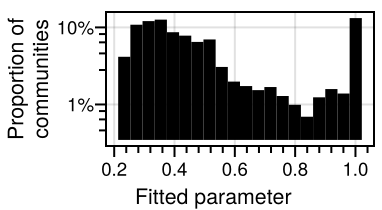

In [9]:
fig = Figure(;
    size=(double_col_width * 0.28, 0.25 * double_col_width / golden_ratio),
    figure_padding=(2., 4., 2., 6.),
)

ax = Axis(fig[1, 1];
    xlabel="Fitted parameter         ",
    ylabel="Proportion of\ncommunities",
    yscale=log10,
    yticks=([0.01,0.1], ["1%", "10%"]),
    xlabelsize=8fontsize_pt,
    ylabelsize=8fontsize_pt,
    xlabelpadding=2.,
    ylabelpadding=2.,
    xticklabelsize=7fontsize_pt,
    yticklabelsize=7fontsize_pt,
    xticklabelpad=0.,
    yticklabelpad=0.,
    yminorticksvisible=true,
    yminorticks=IntervalsBetween(5),
    xminorticksvisible=true,
    xminorticks=IntervalsBetween(5),
)

hist!(ax, adf.fit_d;
    bins=20,
    color=:black,
    normalization=:probability,
)

Makie.save("../../figures2/fig2/fit_d_dist.pdf", fig)

fig

# d dist and fit quality plot

In [13]:
adf.re_h = (adf.mm_h .- adf.si_h) ./ adf.si_h
adf.re_k = (adf.mm_k .- adf.si_k) ./ adf.si_k;

@show maximum(abs, adf.re_h)
@show count(>(1e-7), abs.(adf.re_h))
@show maximum(abs, adf.re_k);

maximum(abs, adf.re_h) = 0.01801165421944691
count((>)(1.0e-7), abs.(adf.re_h)) = 1
maximum(abs, adf.re_k) = 0.2995312411781142

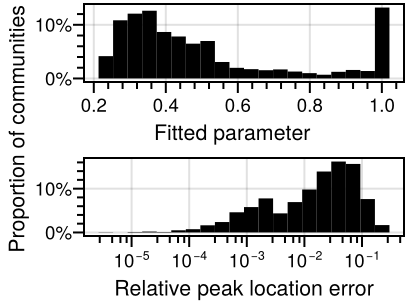

In [60]:
fig = Figure(;
    size=(double_col_width * 0.30, 0.36 * double_col_width / golden_ratio),
    figure_padding=(2., 2., 3., 2.),
)

ax = Axis(fig[1, 1];
    xlabel="Fitted parameter    ",
    # yscale=log10,
    yticks=([0.0,0.1], ["0%", "10%"]),
    xlabelsize=8fontsize_pt,
    xlabelpadding=2.,
    xticklabelsize=7fontsize_pt,
    yticklabelsize=7fontsize_pt,
    xticklabelpad=0.,
    yticklabelpad=0.,
    yminorticksvisible=true,
    yminorticks=IntervalsBetween(5),
    xminorticksvisible=true,
    xminorticks=IntervalsBetween(5),
)

hist!(ax, adf.fit_d;
    bins=20,
    color=:black,
    normalization=:probability,
)

# xtickvals = -5:-1
ax2 = Axis(fig[2, 1];
    xlabel="Relative peak location error",
    xscale=log10,
    xlabelsize=8fontsize_pt,
    xlabelpadding=2.,
    # xticks=(xtickvals, [rich("10", superscript(string(v))) for v in xtickvals]),
    yticks=([0.0,0.1], ["0%", "10%"]),
    xticklabelsize=7fontsize_pt,
    yticklabelsize=7fontsize_pt,
    xticklabelpad=0.,
    yticklabelpad=0.,
    yminorticksvisible=true,
    yminorticks=IntervalsBetween(5),
    xminorticksvisible=true,
    xminorticks=IntervalsBetween(5),
)
# hist!(ax2, re_k;
xx = abs.(re_k)
nbins = 20
edges = 10 .^ range(log10(minimum(xx)), log10(maximum(xx)); length=nbins+1)
hist!(ax2, xx;
    bins=edges,
    normalization=:probability,
    color=:black,
)

Label(fig[1:2,0], "Proportion of communities   ";
    fontsize=8fontsize_pt,
    rotation=pi/2,
)

colgap!(fig.layout, 4.)
rowgap!(fig.layout, 8.)

Makie.save("../../figures2/fig2/d_dist_and_quality_.pdf", fig)

fig

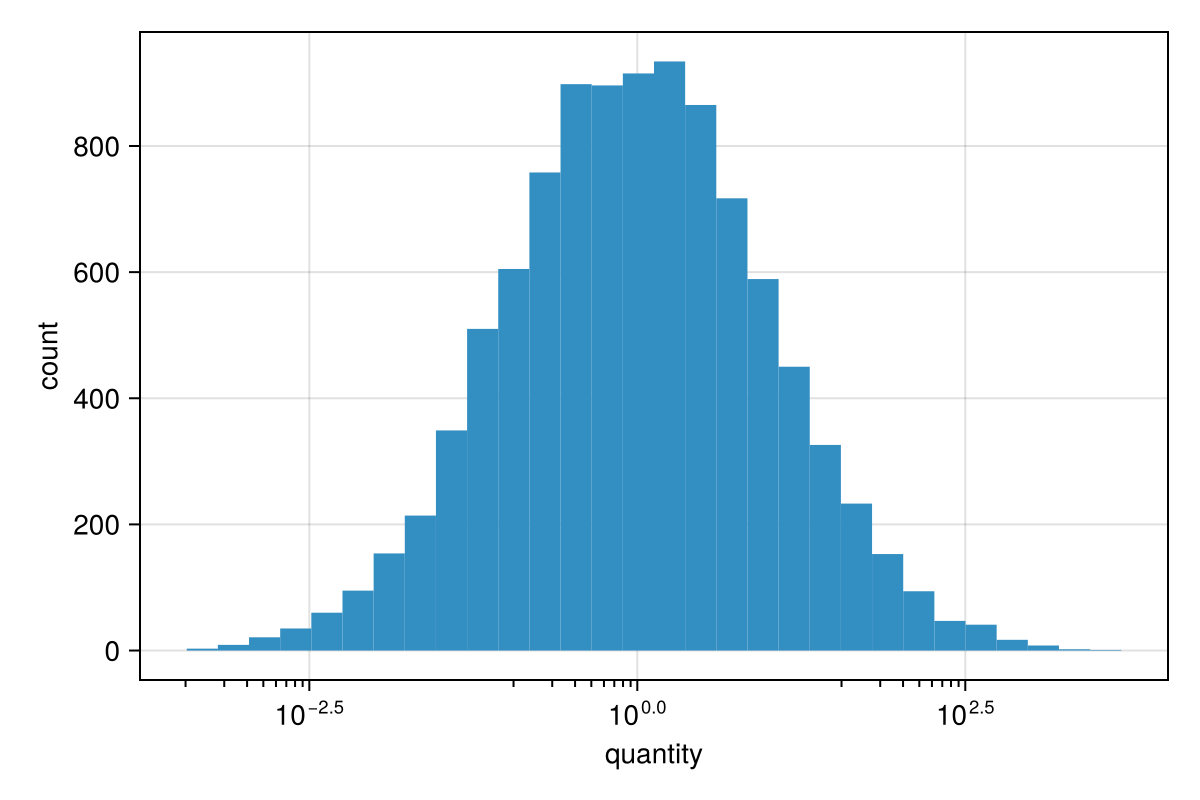

In [46]:
function loghist(x; nbins=30, xlabel="quantity", ylabel="count")
    xp = filter(v -> v > 0 && isfinite(v), x)          # log scale needs x > 0
    edges = 10 .^ range(log10(minimum(xp)), log10(maximum(xp)); length=nbins+1)

    fig = Figure(size=(600, 400))
    ax = Axis(fig[1, 1];
        xscale = log10,
        xlabel, ylabel,
        xminorticks = IntervalsBetween(9),   # 2,3,...,9 within each decade
        xminorticksvisible = true,
    )
    hist!(ax, xp; bins=edges, normalization=:none)
    # xlims!(ax, first(edges), last(edges))
    fig
end

loghist(10 .^ randn(10_000))

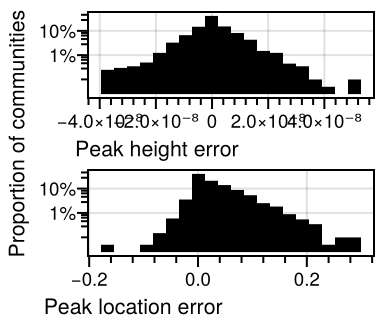

In [12]:
re_h_cap = 1e-7
re_k_cap = 1e-7

re_h = (adf.mm_h .- adf.si_h) ./ adf.si_h
re_k = (adf.mm_k .- adf.si_k) ./ adf.si_k

fig = Figure(;
    size=(double_col_width * 0.28, 0.38 * double_col_width / golden_ratio),
    figure_padding=(2., 4., 2., 6.),
)
ax_kwargs = (;
    yscale=log10,
    xlabelsize=8fontsize_pt,
    xlabelpadding=2.,
    # xticks=(tickvals, [rich("10", superscript(string(e))) for e in tickvals]),
    # yticks=log10ticks(-2:-1),
    yticks=([0.01,0.1], ["1%", "10%"]),
    xticklabelsize=7fontsize_pt,
    yticklabelsize=7fontsize_pt,
    xticklabelpad=0.,
    yticklabelpad=0.,
    yminorticksvisible=true,
    yminorticks=IntervalsBetween(5),
    xminorticksvisible=true,
    xminorticks=IntervalsBetween(5),
)
ax1 = Axis(fig[1, 1];
    xlabel="Peak height error                         ",
    ax_kwargs...,
)
ax2 = Axis(fig[2, 1];
    xlabel="Peak location error                                 ",
    ax_kwargs...,
)
hist!(ax1, filter(x->abs(x)<re_h_cap, re_h);
    bins=20,
    normalization=:probability,
    color=:black,
)
hist!(ax2, re_k;
    bins=20,
    normalization=:probability,
    color=:black,
)
Label(fig[:,0], "Proportion of communities";
    fontsize=8fontsize_pt,
    rotation=pi/2,
)

rowgap!(fig.layout, 6.)
colgap!(fig.layout, 6.)

Makie.save("../../figures2/fig2/fit_metrics2.pdf", fig)

fig

# Example disprel fits

linthresh = 0.0001

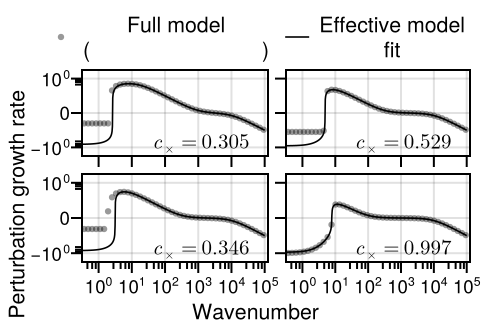

In [173]:
seed = 56
example_is = sort(randperm(Xoshiro(seed), nrow(adf))[1:4])

ydepth = 3. # decades of log range below the tallest peak - this sets linthresh
yup = 5.   # top of the axis, in decades above linthresh
ydown = 5. # bottom of the axis, in decades below -linthresh

# the SI disprel is sampled on all 1000 ks, which is far denser than the panel can
# resolve as markers - show every sistride'th one
sistride = 12
si_kwargs = (; color=(:black, 0.4), markersize=4.5)
mm_kwargs = (; color=:black, linewidth=0.8)

# one y scale shared by all four panels, anchored on the tallest peak of the four,
# so peak heights can be compared across panels
peak = maximum(example_is) do i
    max(maximum(adf[i, :si_mrls]), maximum(adf[i, :mmls]))
end
linthresh = 10. ^ (floor(log10(peak)) - ydepth)
# linthresh = 1.
@show linthresh

yticksfn = CustomSymlogScale.ticks(linthresh; max_ticks=4, trim=1e0)
# yticksfn = CustomSymlogScale.ticks([-100,-10,-1,1,10,100])
ylo, yhi = -linthresh * 10^ydown, linthresh * 10^yup

fig = Figure(;
    # size=(double_col_width * 0.48, 0.55 * double_col_width / golden_ratio),
    size=(double_col_width * 0.36, 0.39 * double_col_width / golden_ratio),
    figure_padding=(2., 10., 2., 6.),
)

axs = Axis[]
for (n, i) in enumerate(example_is)
    r = adf[i, :]
    row, col = fldmod1(n, 2)

    kks, si_mrls, mmls = ks, r.si_mrls, r.mmls

    ax = Axis(fig[row, col];
        xscale=log10,
        CustomSymlogScale.kwargs(linthresh; max_ticks=5, nminor=4)...,
        yticks=yticksfn,
        xticks=log10ticks(0:5),
        xminorticksvisible=true,
        xminorticks=IntervalsBetween(5),
        xticklabelsize=7fontsize_pt,
        yticklabelsize=7fontsize_pt,
        xticklabelpad=0.,
        yticklabelpad=0.,
    )

    scatter!(ax, kks[1:sistride:end], si_mrls[1:sistride:end]; si_kwargs...)
    lines!(ax, kks, mmls; mm_kwargs...)

    text!(ax, 0.9, 0.01;
        text=latexstring(@sprintf "c_\\times=%.3g" r.fit_d),
        space=:relative,
        align=(:right, :bottom),
        justification=:right,
        fontsize=7fontsize_ltex_pt,
    )

    # xlims!(ax, extrema(kks)...)
    xlims!(ax, 10^-0.5, 10^5.1)
    ylims!(ax, ylo, yhi)

    # both scales are shared, so only label each one once
    col == 2 && hideydecorations!(ax; ticks=false, grid=false)
    row == 1 && hidexdecorations!(ax; ticks=false, grid=false)
    push!(axs, ax)
end
linkaxes!(axs...)

Label(fig[1:2, 0], "Perturbation growth rate             ";
    fontsize=8fontsize_pt,
    rotation=pi/2,
    padding=(0., 2., 0., 0.),
)
Label(fig[3, 1:2], "Wavenumber       ";
    fontsize=8fontsize_pt,
    padding=(0., 0., 0., 2.),
)
Legend(fig[0, 0:2],
    [MarkerElement(; marker=:circle, si_kwargs...), LineElement(; mm_kwargs...)],
    ["Full model\n(                             )", "Effective model\nfit"];
    orientation=:horizontal,
    labeljustification=:center,
    labelsize=8fontsize_pt,
    framevisible=false,
    padding=(20., 0., 0., 0.),
    patchsize=(12., 6.),
    colgap=8.,
)

rowgap!(fig.layout, 4.)
colgap!(fig.layout, 4.)
colgap!(fig.layout, 1, 0.)
rowgap!(fig.layout, 1, 4.) # legend to panels
rowgap!(fig.layout, 3, 0.) # panels to x label

Makie.save("../../figures2/fig2/disprel_examples.pdf", fig)

fig


# Peak fitting stats (OLD, has both)

In [85]:
adf.deltak = log10.(adf.mm_k ./ adf.si_k)
adf.deltah = log10.(adf.mm_h ./ adf.si_h);

In [86]:
count(>(1e-3), abs.(adf.deltah))

0

(count(.!(inliers)), length(inliers)) = (0, 213)

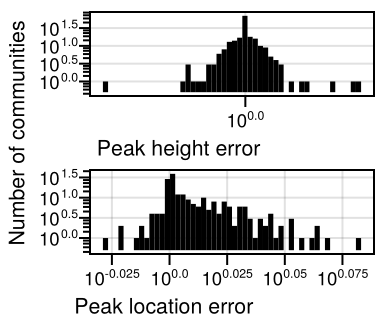

In [101]:
kcut, hcut = Inf, Inf

inliers = (abs.(adf.deltak) .<= kcut) .& (abs.(adf.deltah) .<= hcut)
@show count(.!inliers), length(inliers)
deltak, deltah = adf.deltak[inliers], adf.deltah[inliers]

fig = Figure(;
    size=(double_col_width * 0.28, 0.38 * double_col_width / golden_ratio),
    figure_padding=(2., 4., 2., 6.),
)
tickvals = -0.025:0.025:0.075
ax_kwargs = (;
    yscale=log10,
    xlabelsize=8fontsize_pt,
    xlabelpadding=2.,
    xticks=(tickvals, [rich("10", superscript(string(e))) for e in tickvals]),
    xticklabelsize=7fontsize_pt,
    yticklabelsize=7fontsize_pt,
    xticklabelpad=0.,
    yticklabelpad=0.,
    yminorticksvisible=true,
    yminorticks=IntervalsBetween(5),
)
ax1 = Axis(fig[1, 1];
    xlabel="Peak height error                  ",
    ax_kwargs...,
)
ax2 = Axis(fig[2, 1];
    xlabel="Peak location error                       ",
    ax_kwargs...,
)
hist!(ax1, deltah;
    bins=50,
    color=:black,
)
hist!(ax2, deltak;
    bins=50,
    color=:black,
)
Label(fig[:,0], "Number of communities";
    fontsize=8fontsize_pt,
    rotation=pi/2,
)

rowgap!(fig.layout, 6.)
colgap!(fig.layout, 6.)

Makie.save("../../figures2/fig2/fit_metrics.pdf", fig)

fig